# Такс это моя первая кластеризация

In [2]:
from sklearn.datasets import load_iris
import numpy as np 
import matplotlib.pyplot as plt

data = load_iris()
X = data.data

print('Размер выборки:', X.shape)
print('Признаки:', data.feature_names)
print('Первые 5 строк:')
print(X[:5])

Размер выборки: (150, 4)
Признаки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Первые 5 строк:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


0.6810461692117462
0.5528190123564095
0.497455189017375
0.48997211669094676


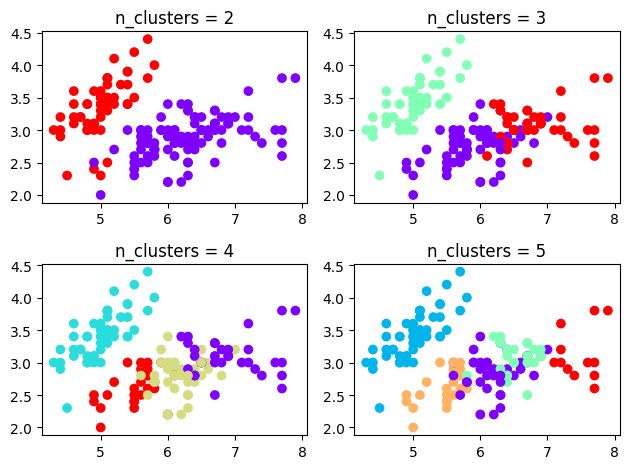

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


for n_c in range(2, 6):
    kmeans = KMeans(n_clusters = n_c)
    kmeans = kmeans.fit(X)
    clusters = kmeans.predict(X)

    score = silhouette_score(X, clusters)
    print(score)
    
    plt.subplot(2, 2, n_c - 1)
    plt.scatter(X[:,0], X[:,1], c = clusters, cmap='rainbow')
    plt.title("n_clusters = {}".format(n_c))

plt.tight_layout()
plt.show()

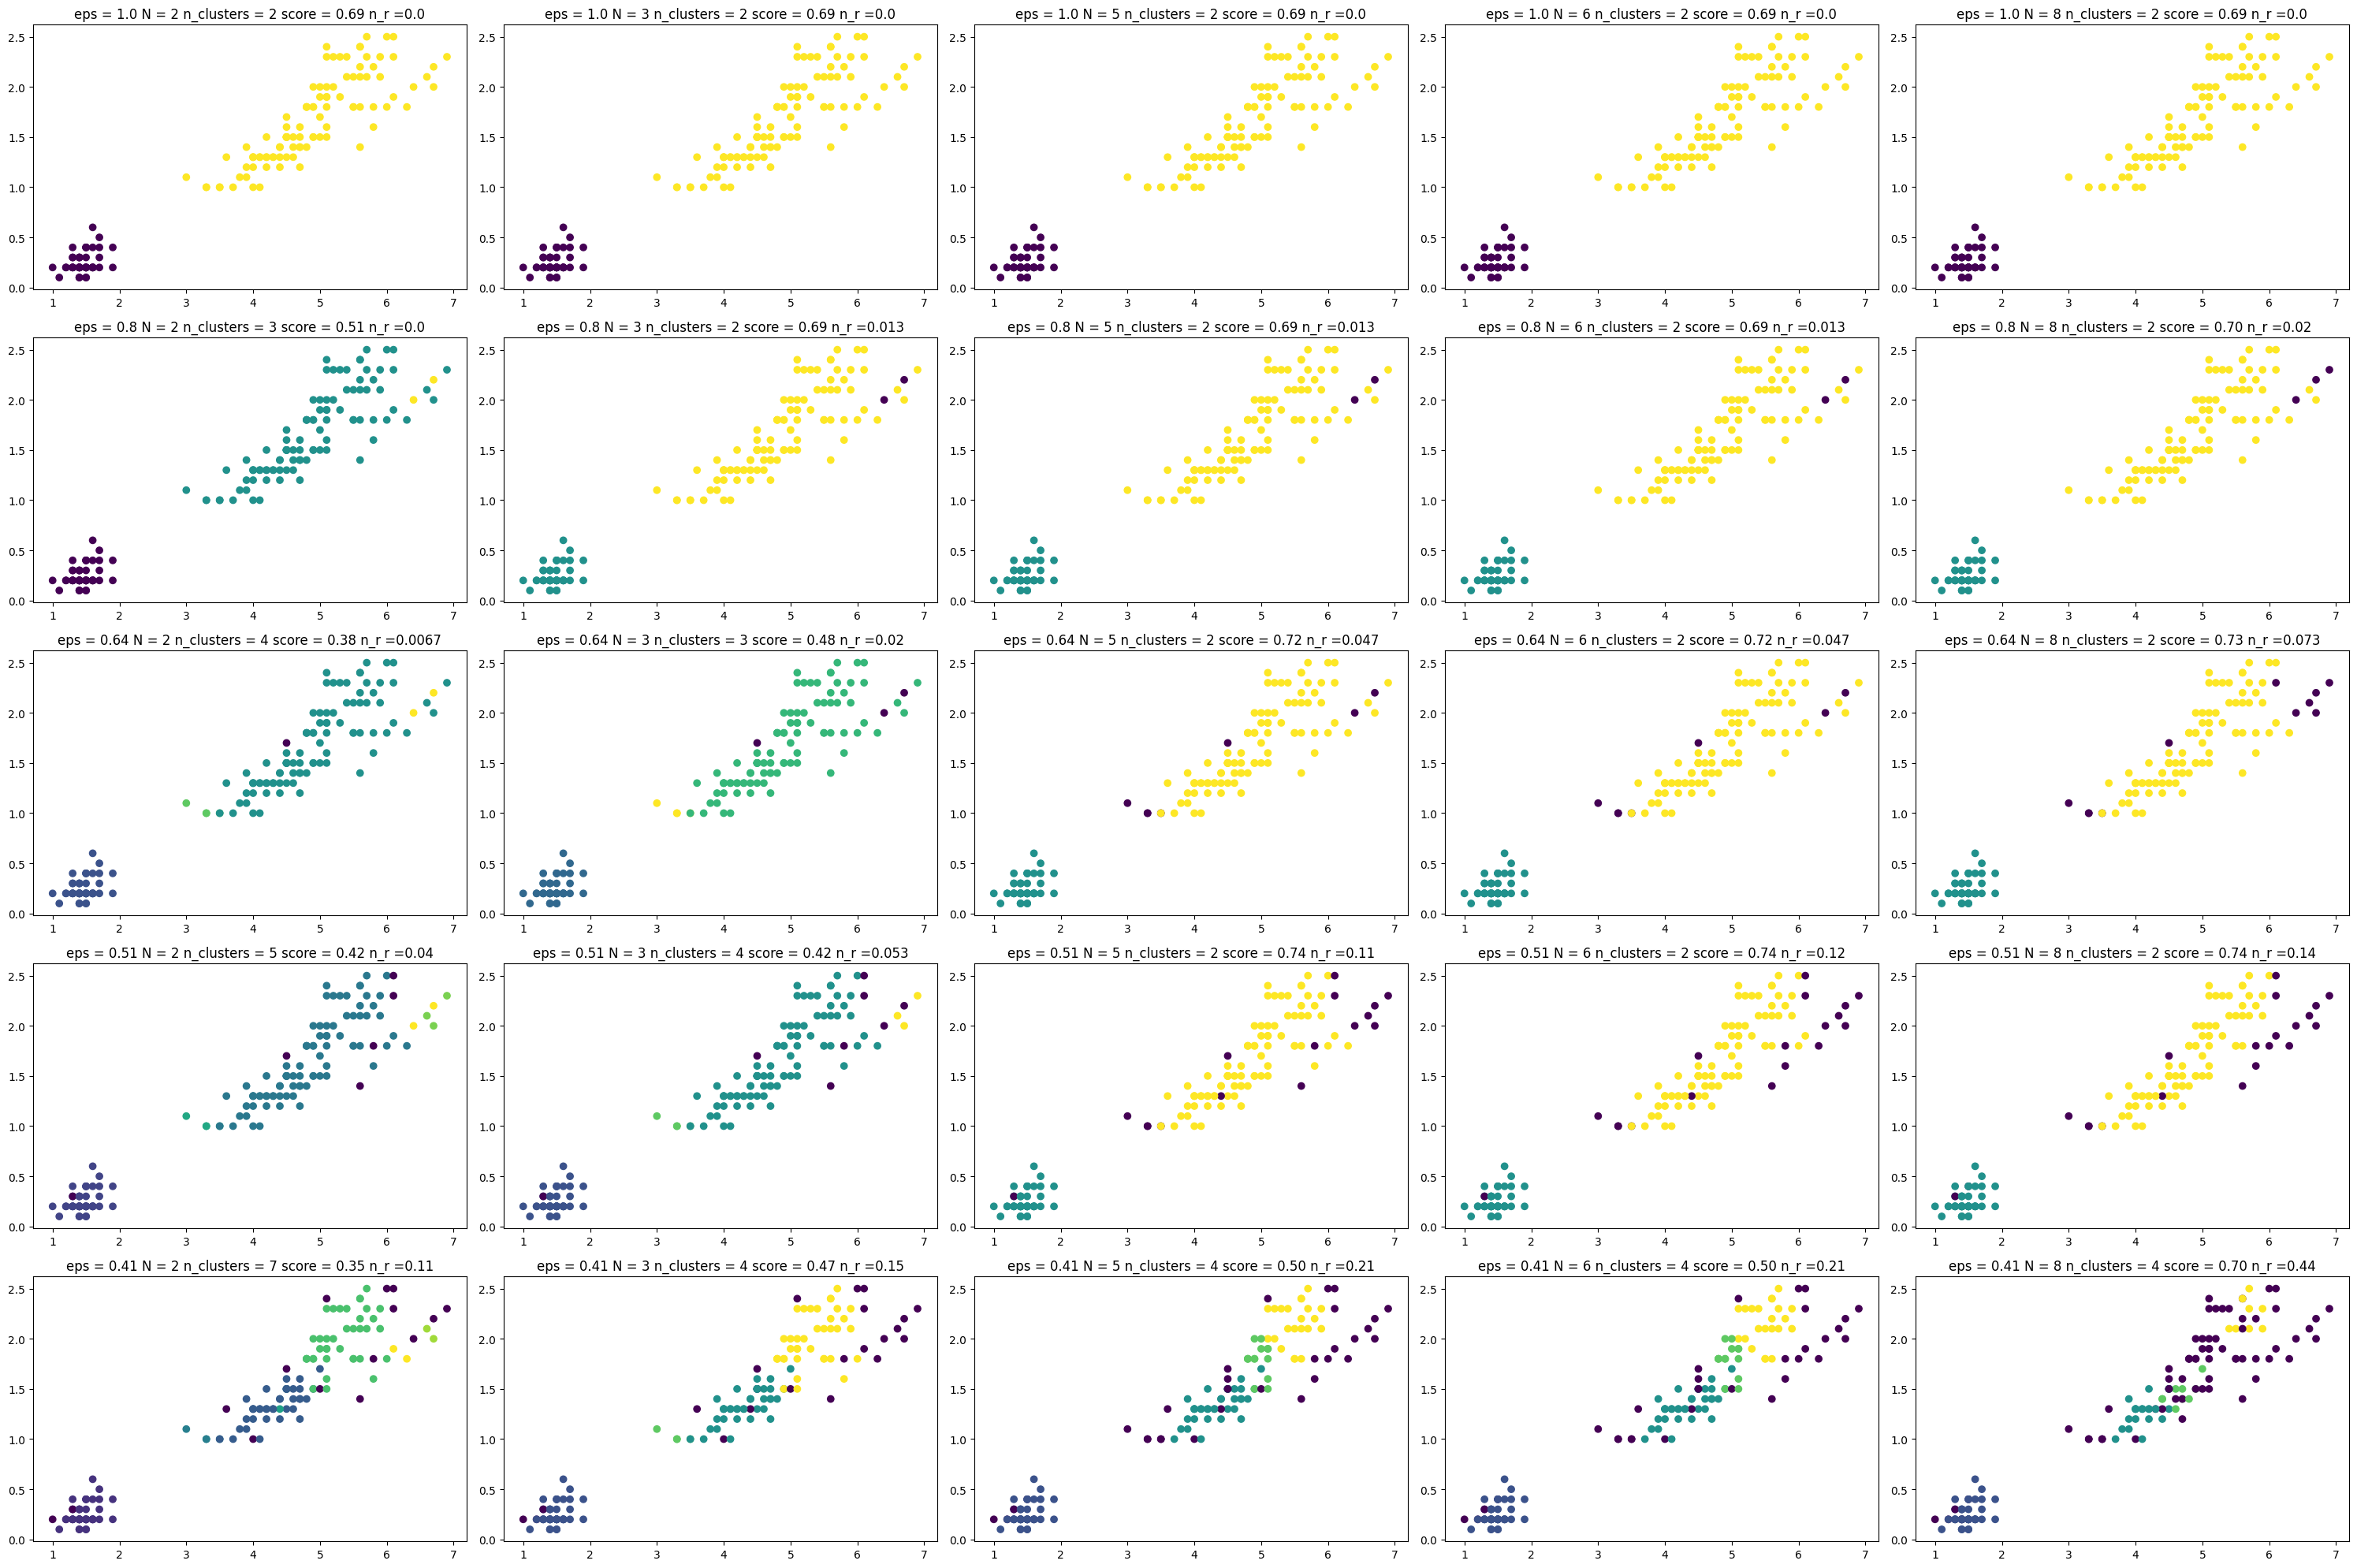

In [23]:
from sklearn.cluster import DBSCAN

i = 0
plt.figure(figsize=(30, 20))

for eps in 0.8**np.arange(5):
    for N in [2, 3, 5, 6, 8]:
        i += 1
        dbscan = DBSCAN(eps = eps, min_samples = N)
        clusters = dbscan.fit_predict(X)
        n_clusters = len(np.unique(clusters[clusters != -1]))

        if n_clusters >= 2:
            mask = clusters != -1
            score = silhouette_score(X[mask], clusters[mask])
        else:
            score = -1

        noise_ratio = (clusters == -1).sum() / len(clusters)

        plt.subplot(5, 5, i)
        plt.scatter(X[:,2], X[:,3], c = clusters)
        plt.title("eps = {:.2} N = {} n_clusters = {} score = {:.2f} n_r ={:.2}".format(eps, N, n_clusters, score, noise_ratio))

plt.tight_layout()
plt.show()       

## Вывод:
Был взят датасет Iris (150 цветков, 4 признака)
Применены методы Kmeans и DBSCAN. Метрика качества - silhouette
### Kmeans
Лучший результат показал при 2 кластерах, силуэт 0.68
При увелечении количества кластеров силуэт падает.
### DBSCAN
Здесь уже все не так очевидно
Лучший силуэт 0.74 достигается при eps = 0.51, samples = 8, но показатель шума близок к 15%
При eps = 1, samples = 2, силуэт 0.69, но показатель шума 0%

Оба метода сошлись на 2 кластерах. Это расходится с реальной разметкой (в Iris 3 вида), так как два вида (versicolor и virginica) сильно пересекаются по признакам и воспринимаются как один кластер.



# Такс это моя вторая кластреизация
## Датасет вина


In [2]:
from sklearn.datasets import load_wine


data = load_wine()

X = data.data
Y = data.target

print("Размер выборки: ", X.shape)
print('Признаки:', data.feature_names)
print('Классы:', data.target_names)
print('Первые 3 строки:')
print(X[:3])

Размер выборки:  (178, 13)
Признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Классы: ['class_0' 'class_1' 'class_2']
Первые 3 строки:
[[1.423e+01 1.710e+00 2.430e+00 1.560e+01 1.270e+02 2.800e+00 3.060e+00
  2.800e-01 2.290e+00 5.640e+00 1.040e+00 3.920e+00 1.065e+03]
 [1.320e+01 1.780e+00 2.140e+00 1.120e+01 1.000e+02 2.650e+00 2.760e+00
  2.600e-01 1.280e+00 4.380e+00 1.050e+00 3.400e+00 1.050e+03]
 [1.316e+01 2.360e+00 2.670e+00 1.860e+01 1.010e+02 2.800e+00 3.240e+00
  3.000e-01 2.810e+00 5.680e+00 1.030e+00 3.170e+00 1.185e+03]]


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

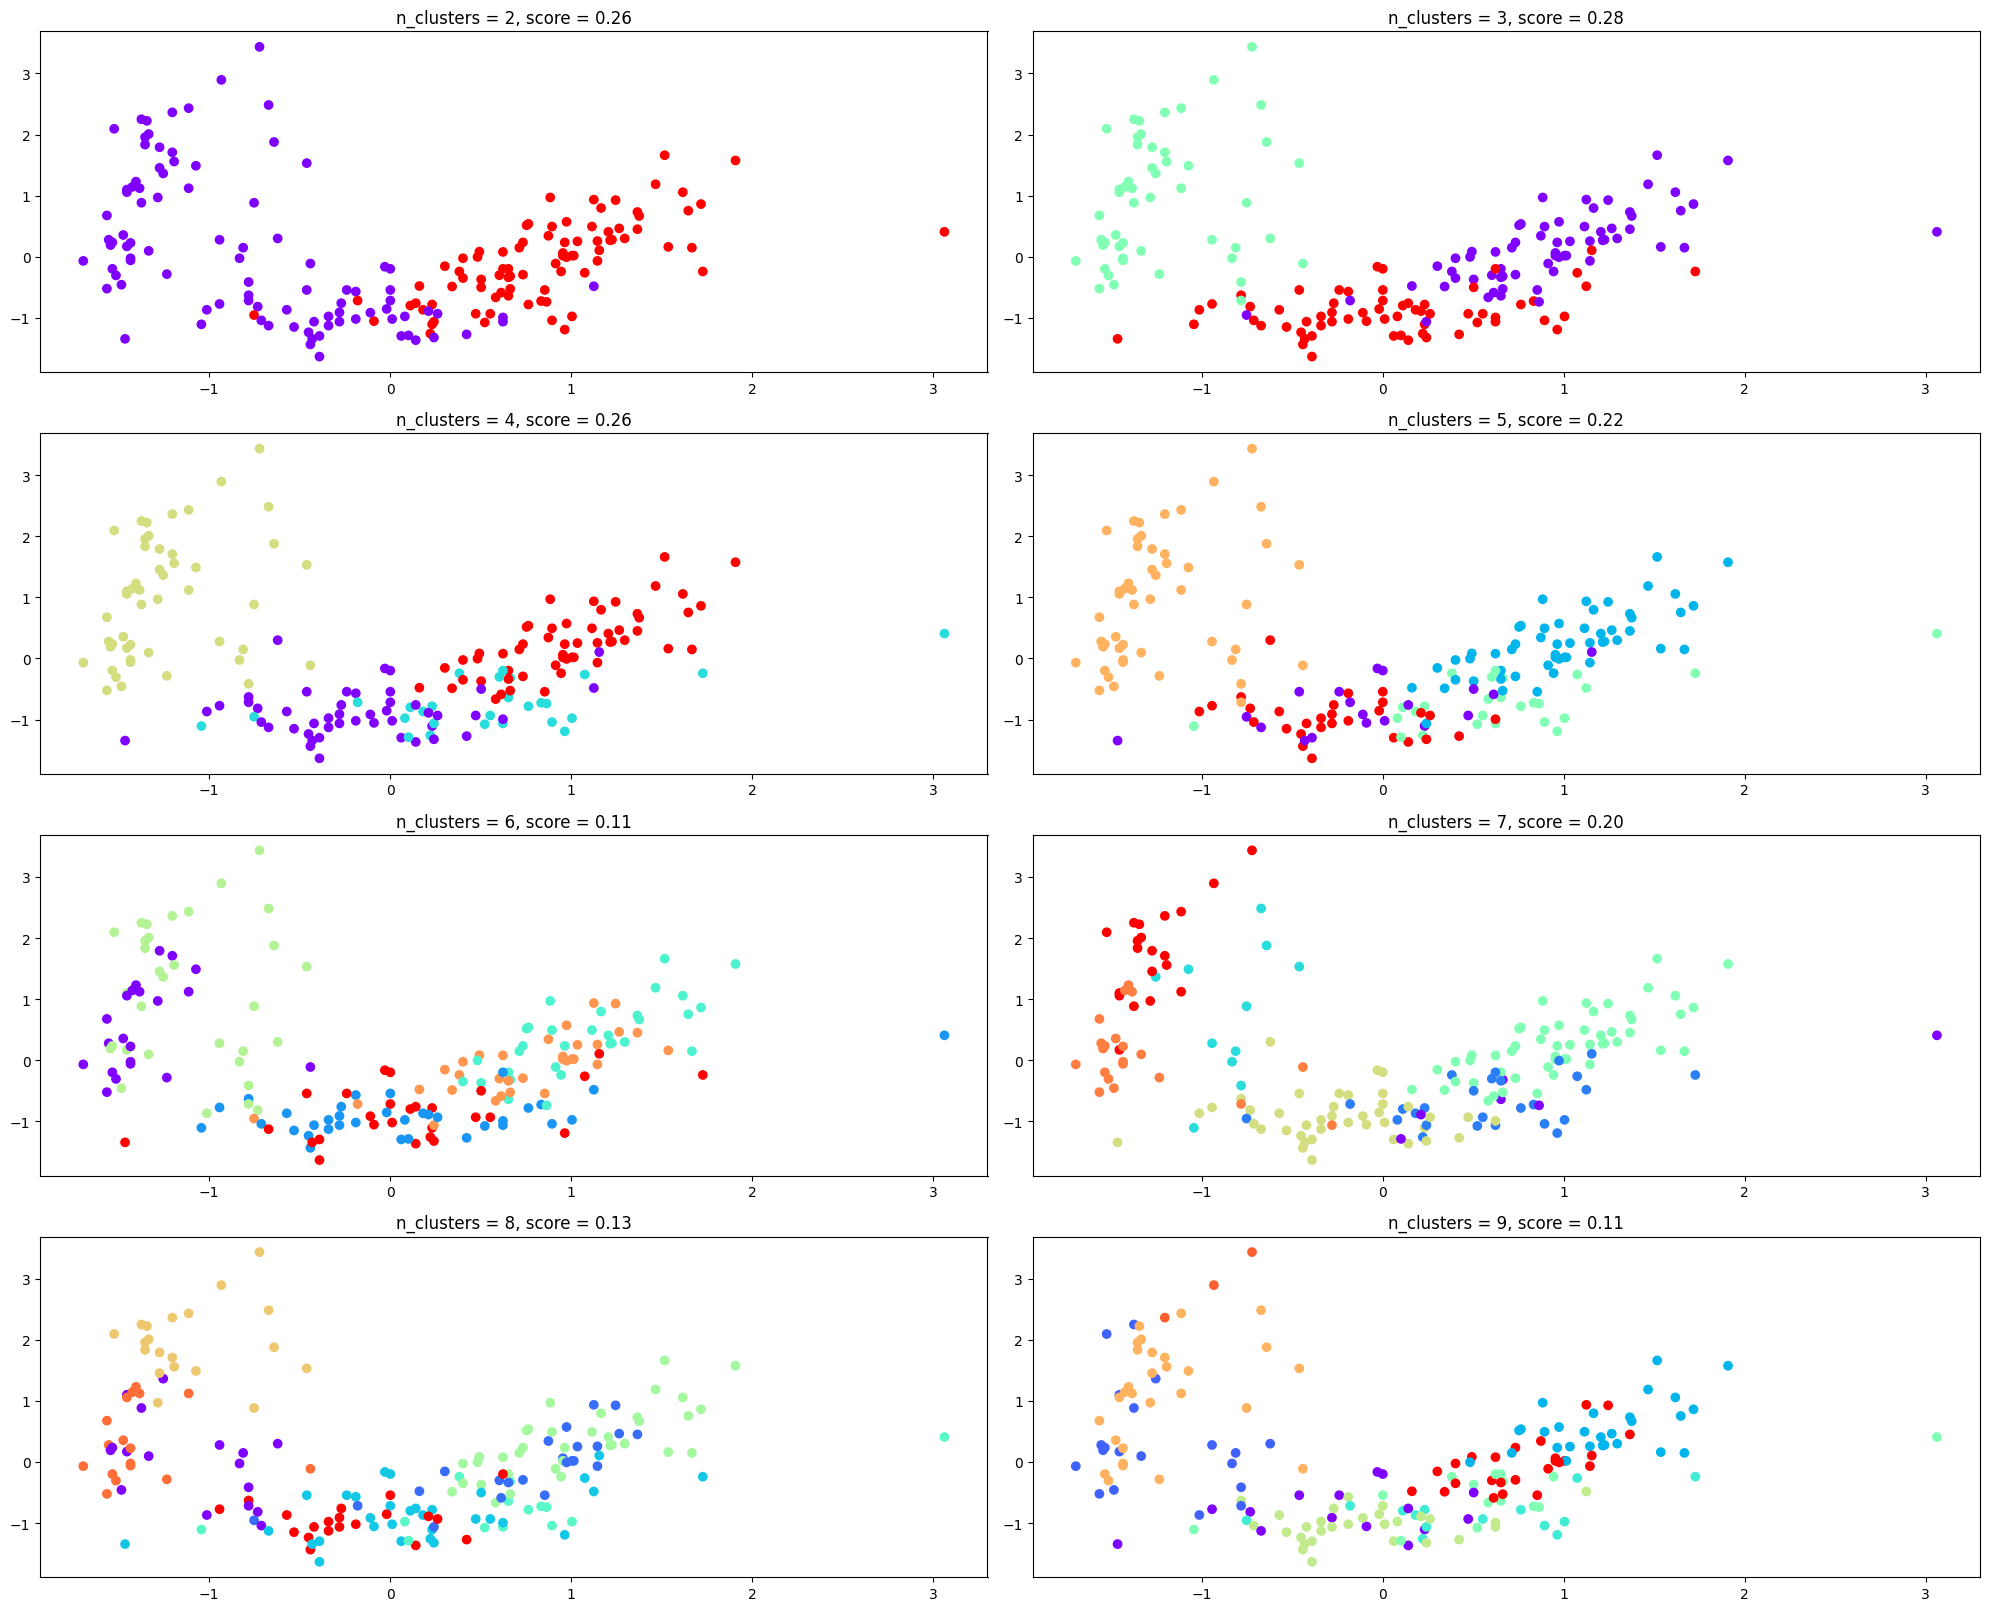

In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 20))


for n_c in range(2, 10):
    kmeans = KMeans(n_clusters = n_c)
    kmeans = kmeans.fit(X_scaled)
    clusters = kmeans.predict(X_scaled)

    score = silhouette_score(X_scaled, clusters)

    plt.subplot(5, 2, n_c - 1)
    plt.scatter(X_scaled[:,6], X_scaled[:,9], c = clusters, cmap='rainbow')
    plt.title("n_clusters = {}, score = {:.2f}".format(n_c, score))

plt.tight_layout()
plt.show()

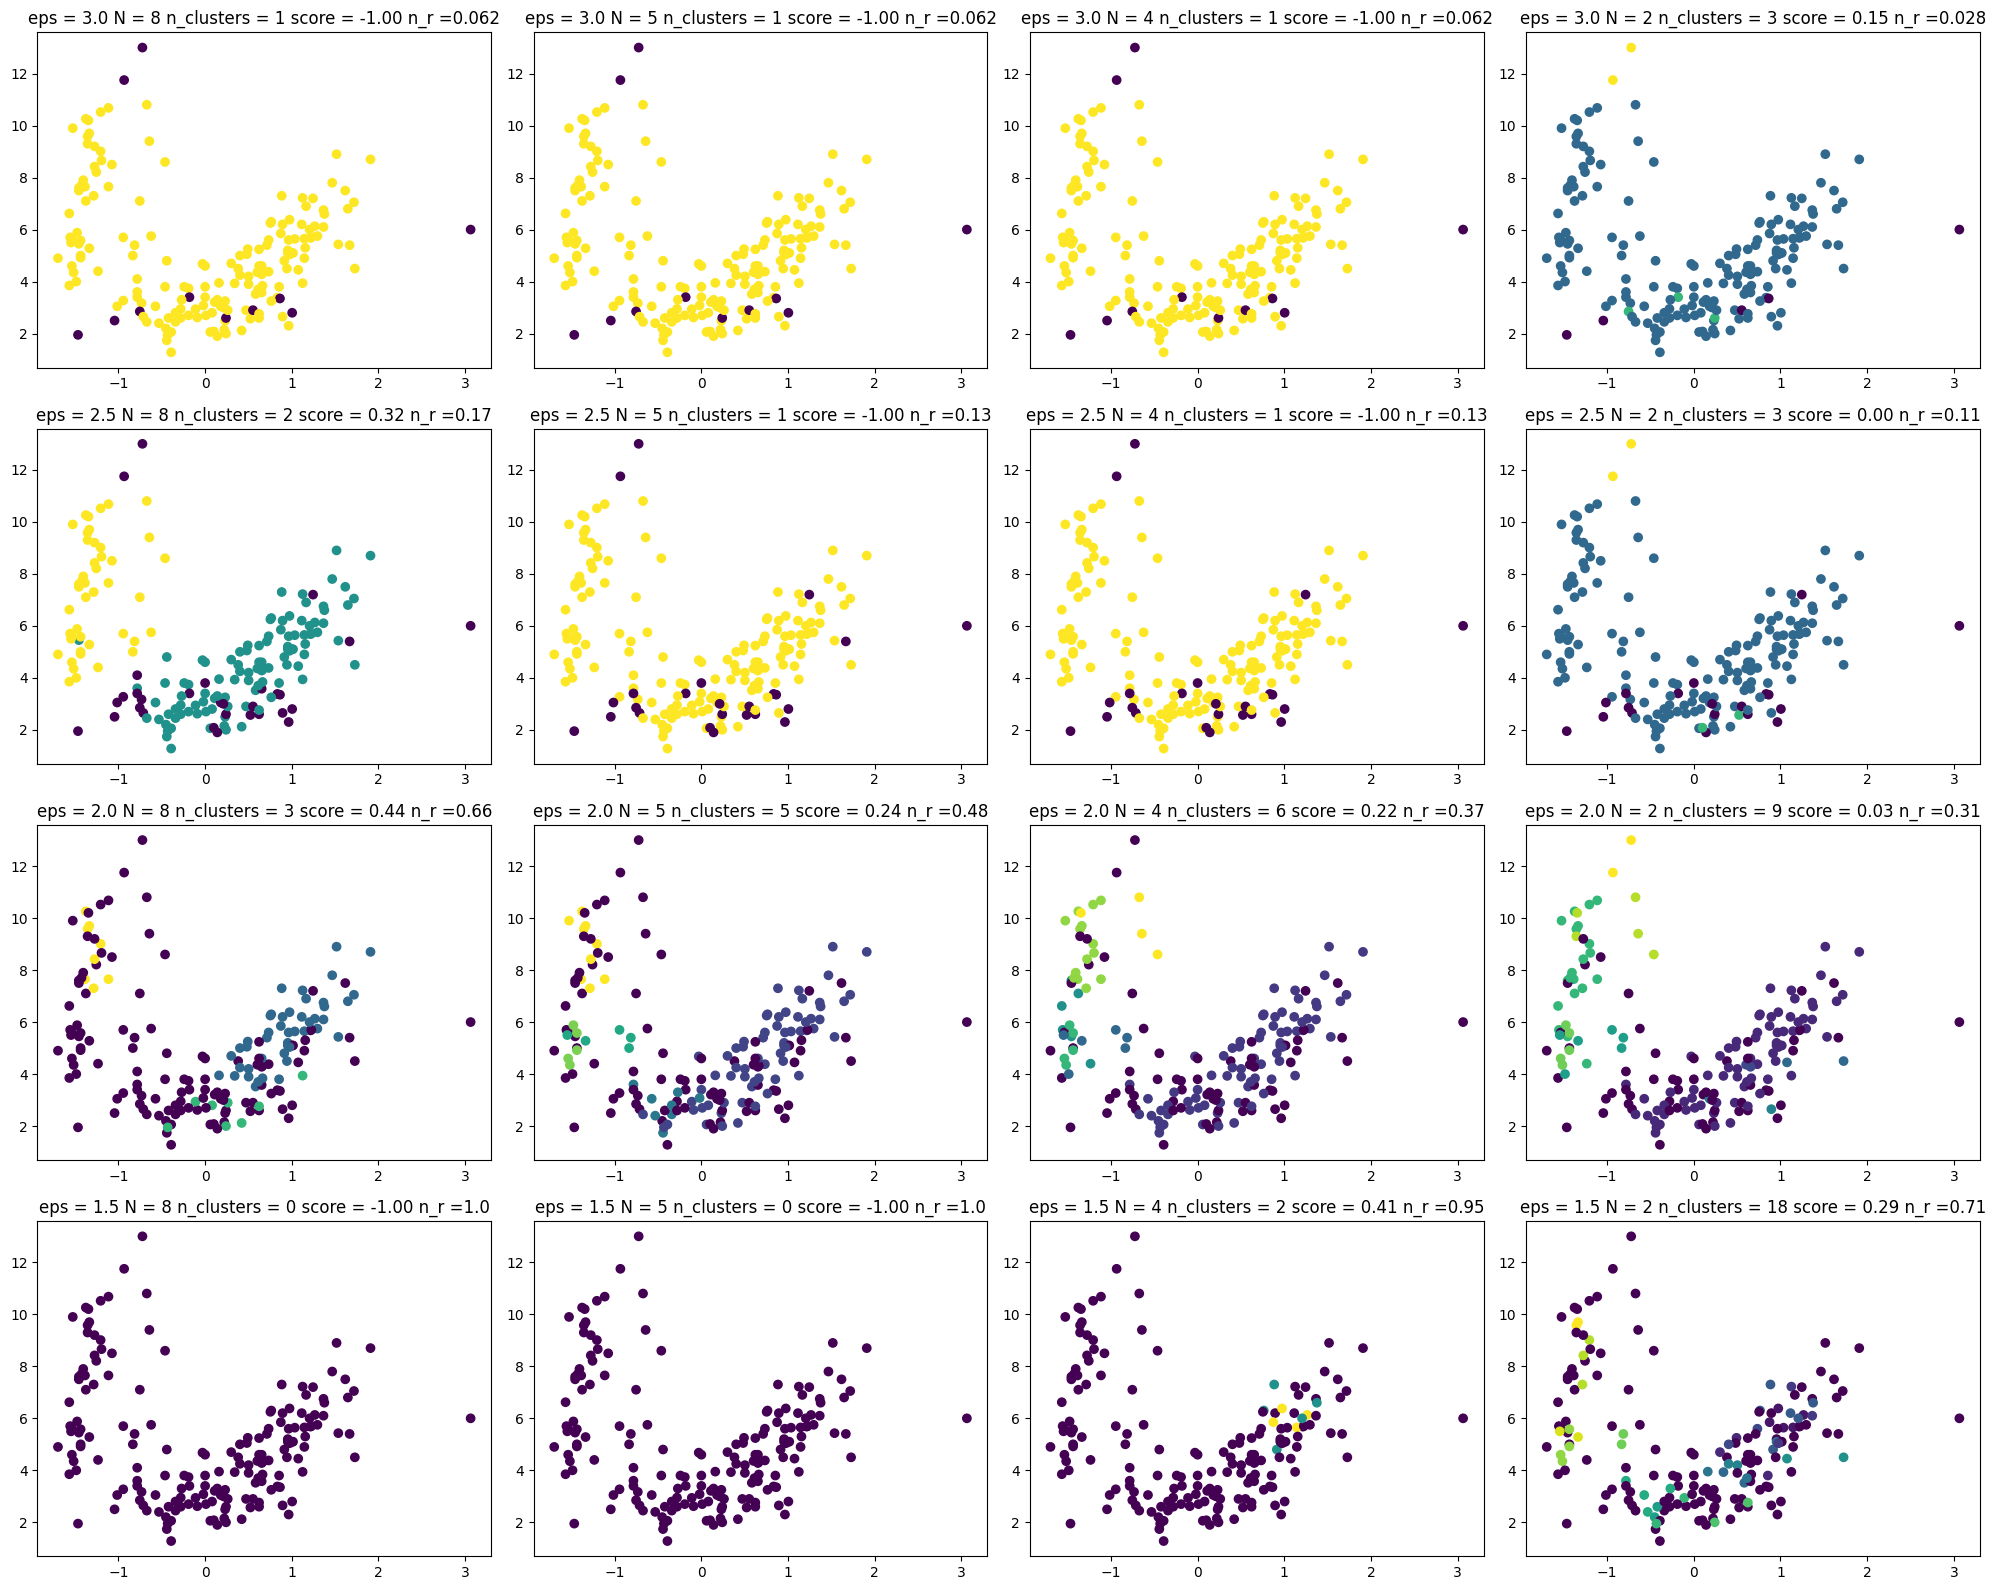

In [39]:
from sklearn.cluster import DBSCAN
import numpy as np

i = 0
plt.figure(figsize=(20, 16))

for e in [3.0, 2.5, 2.0, 1.5]:
    for samples in [8, 5, 4, 2]:
        i += 1
        
        dbscan = DBSCAN(eps=e, min_samples=samples)
        clusters = dbscan.fit_predict(X_scaled)
        n_clusters = len(np.unique(clusters[clusters != -1]))

        if n_clusters >= 2:
            mask = clusters != -1
            score = silhouette_score(X_scaled[mask], clusters[mask])
        else:
            score = -1

        noise_ratio = (clusters == -1).sum() / len(clusters)
        plt.subplot(4, 4, i)
        plt.scatter(X_scaled[:,6], X_scaled[:,9], c = clusters)
        plt.title("eps = {:.2} N = {} n_clusters = {} score = {:.2f} n_r ={:.2}".format(e, samples, n_clusters, score, noise_ratio))

plt.tight_layout()
plt.show()           